## 1. Import libraries


In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Splitting
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

In [2]:
## 2. Load the dataset

In [3]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. Explore the data


In [4]:
df.shape

(100000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3854)

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

df.shape

(96146, 9)

# Data Visualization

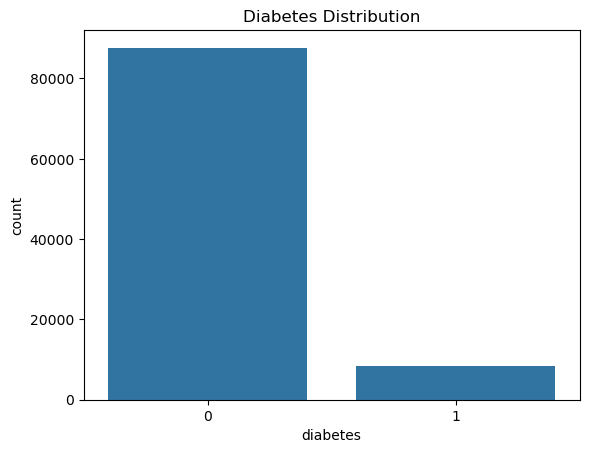

In [10]:
# Show the number of people with and without diabetes
sns.countplot(x='diabetes', data=df)
plt.title('Diabetes Distribution')
plt.show()

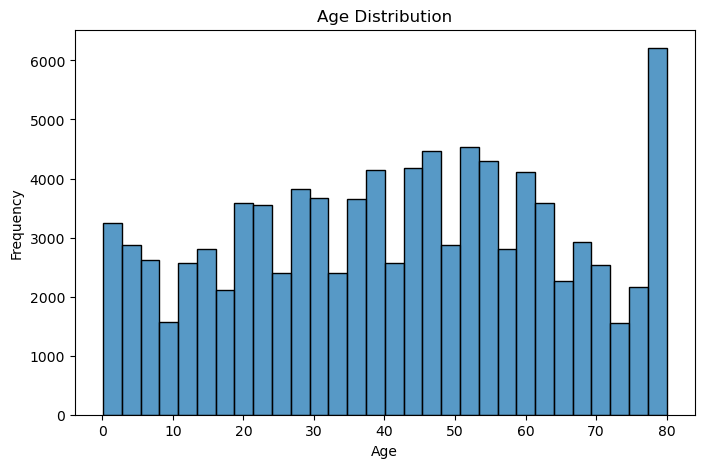

In [11]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

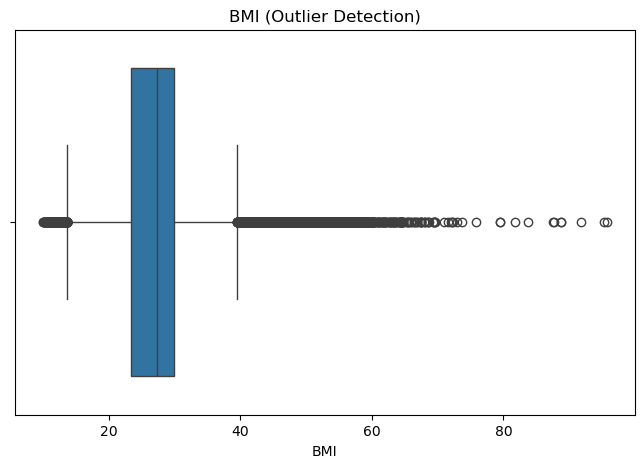

In [12]:
# BMI distribution to show  outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bmi'])
plt.title('BMI (Outlier Detection)')
plt.xlabel('BMI')
plt.show()

## Keep outliers because they may be real medical cases

# Preprocessing

In [13]:

# Make a copy
data = df.copy()

# Gender
g = LabelEncoder()
data['gender'] = g.fit_transform(data['gender'])

# Smoking history
s = LabelEncoder()
data['smoking_history'] = s.fit_transform(data['smoking_history'])

data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [14]:
# Features (everything except the target column)
X = data.drop('diabetes', axis=1)

# Target (what we want to predict)
y = data['diabetes']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96146, 8)
y shape: (96146,)


# Scaling

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [16]:

scaler = StandardScaler()

# Fit on training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform the test data
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model

In [17]:

# Initialize the model
log_reg = LogisticRegression(random_state=42)

# Train the model on the scaled training data
log_reg.fit(X_train_scaled, y_train)

print(" Done Model trained ")

 Done Model trained 


In [18]:
# Predictions (class labels: 0 or 1)
y_pred = log_reg.predict(X_test_scaled)

# Predictions (probabilities - needed later for ROC Curve)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

#Accuracy is high, but Recall is lower because the dataset is imbalanced?
#Because we want to detect as many diabetes cases as possible

Accuracy: 0.9586049091665511
Precision: 0.8618103910016068
Recall: 0.6322200392927309
F1 Score: 0.7293744333635539


# Confusion Matrix

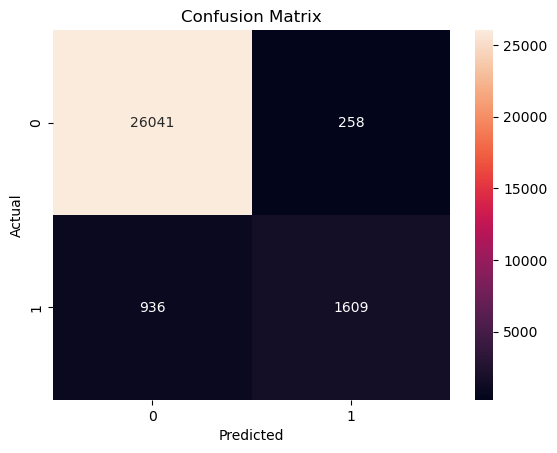

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred,
                            target_names=['No Diabetes', 'Diabetes']))

#The model has high accuracy, but the recall for diabetes is only 63%, so it misses some real diabetes cases.

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     26299
    Diabetes       0.86      0.63      0.73      2545

    accuracy                           0.96     28844
   macro avg       0.91      0.81      0.85     28844
weighted avg       0.96      0.96      0.96     28844



In [22]:

auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC:", auc)


#ROC-AUC measures how well the model separates diabetes from no diabetes.

ROC-AUC: 0.9593929744465771


In [23]:
# Final threshold

t = 0.3

y_pred_final = (y_pred_proba >= t).astype(int)

print("Threshold:", t)
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

Threshold: 0.3
Accuracy: 0.949486895021495
Precision: 0.7135007849293563
Recall: 0.7143418467583497
F1 Score: 0.7139210681327312


In [24]:

scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='f1')

print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.71117705 0.7333975  0.73489279 0.74466019 0.72762458]
Mean F1: 0.7303504216794975


# SVM

In [25]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', probability=True, random_state=42)

svm_linear.fit(X_train_scaled, y_train)

print("SVM trained successfully")

SVM trained successfully


In [26]:
y_pred_svm = svm_linear.predict(X_test_scaled)

y_pred_proba_svm = svm_linear.predict_proba(X_test_scaled)[:, 1]

In [27]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)

Accuracy: 0.9588475939536819
Precision: 0.9085439229843562
Recall: 0.593320235756385
F1 Score: 0.7178512003803185


# confusion_matrix

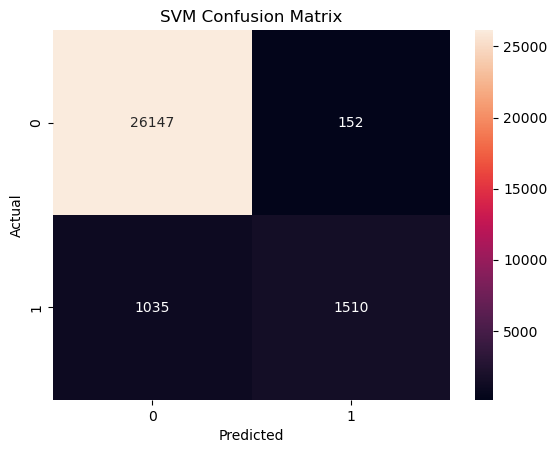

In [28]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report

In [30]:
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=['No Diabetes', 'Diabetes']
))

              precision    recall  f1-score   support

 No Diabetes       0.96      0.99      0.98     26299
    Diabetes       0.91      0.59      0.72      2545

    accuracy                           0.96     28844
   macro avg       0.94      0.79      0.85     28844
weighted avg       0.96      0.96      0.95     28844



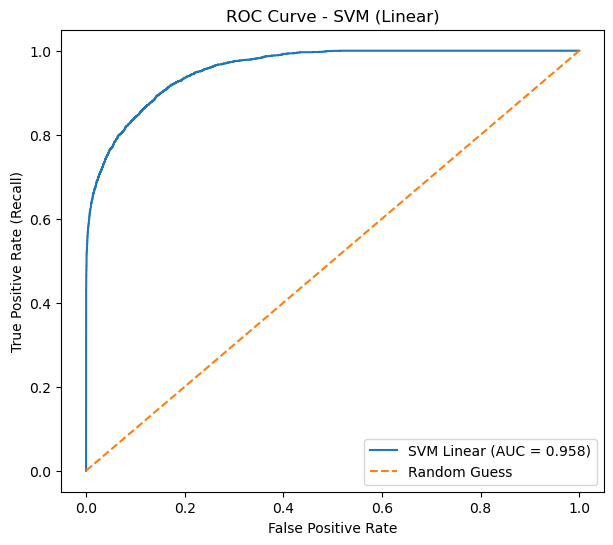

ROC-AUC Score (SVM): 0.9576


In [31]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_proba_svm)
auc_svm = roc_auc_score(y_test, y_pred_proba_svm)

plt.figure(figsize=(7,6))

plt.plot(fpr_svm, tpr_svm, label=f'SVM Linear (AUC = {auc_svm:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - SVM (Linear)')
plt.legend()
plt.show()

print(f"ROC-AUC Score (SVM): {auc_svm:.4f}")

,Threshold,Precision,Recall,F1 Score,False Negatives,False Positives
0,0.5,0.866,0.626,0.726,953,246
1,0.4,0.807,0.661,0.727,862,403
2,0.3,0.716,0.705,0.711,751,710
3,0.2,0.604,0.765,0.675,599,1277
4,0.1,0.448,0.843,0.585,399,2648


In [33]:
# Final threshold - SVM
t_svm = 0.3
y_pred_svm_final = (y_pred_proba_svm >= t_svm).astype(int)

print("Threshold:", t_svm)
print("Accuracy:", accuracy_score(y_test, y_pred_svm_final))
print("Precision:", precision_score(y_test, y_pred_svm_final))
print("Recall:", recall_score(y_test, y_pred_svm_final))
print("F1 Score:", f1_score(y_test, y_pred_svm_final))

Threshold: 0.3
Accuracy: 0.9493482180002774
Precision: 0.7164536741214057
Recall: 0.7049115913555992
F1 Score: 0.7106357694592988


In [34]:
scores_svm = cross_val_score(svm_linear, X_train_scaled, y_train, cv=5, scoring='f1')

print("F1 scores (SVM):", scores_svm)
print("Mean F1 (SVM):", scores_svm.mean())

F1 scores (SVM): [0.70010449 0.72578165 0.72920892 0.73646578 0.72052846]
Mean F1 (SVM): 0.7224178610574119


In [3]:
# Final Model Comparison Table

comparison_data = {
    'Model': ['Logistic Regression', 'SVM (Linear)'],
    'Accuracy (t=0.3)': [0.9495, 0.9493],
    'Precision (t=0.3)': [0.7135, 0.7165],
    'Recall (t=0.3)': [0.7143, 0.7049],
    'F1 Score (t=0.3)': [0.7139, 0.7106],
    'ROC-AUC': [0.9594, 0.9576],
    'CV Mean F1 (5-Fold)': [0.7304, 0.7224]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Model')
comparison_df

,Accuracy (t=0.3),Precision (t=0.3),Recall (t=0.3),F1 Score (t=0.3),ROC-AUC,CV Mean F1 (5-Fold)
Model,,,,,,
Logistic Regression,0.9495,0.7135,0.7143,0.7139,0.9594,0.7304
SVM (Linear),0.9493,0.7165,0.7049,0.7106,0.9576,0.7224


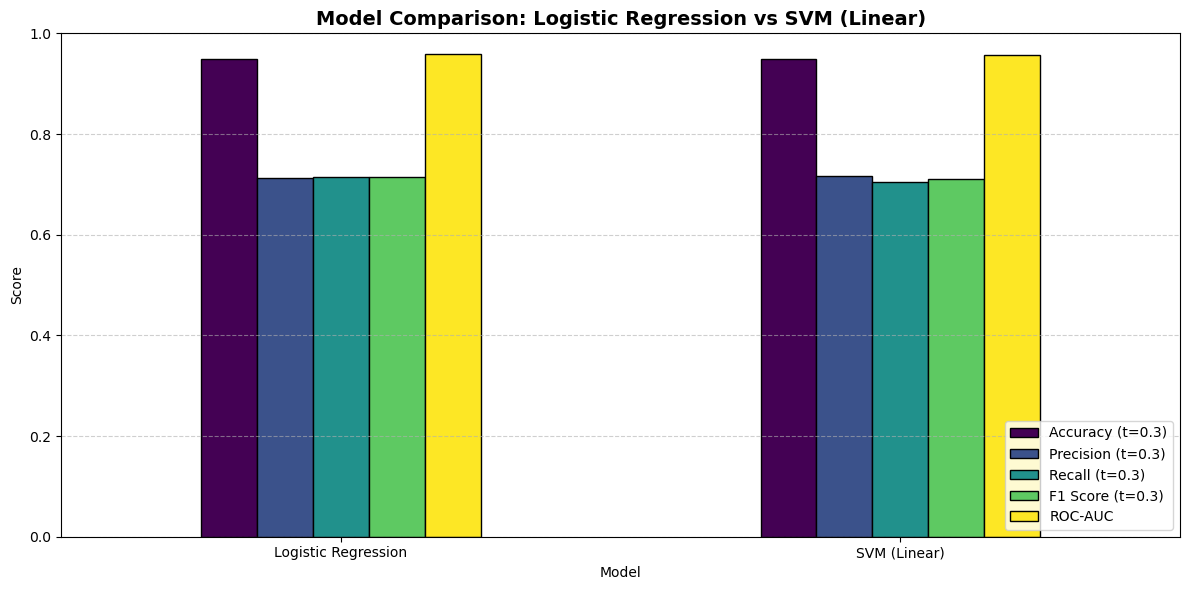

In [4]:
metrics_to_plot = ['Accuracy (t=0.3)', 'Precision (t=0.3)', 'Recall (t=0.3)', 'F1 Score (t=0.3)', 'ROC-AUC']

comparison_df[metrics_to_plot].plot(
    kind='bar', figsize=(12,6), colormap='viridis', edgecolor='black'
)
plt.title('Model Comparison: Logistic Regression vs SVM (Linear)', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [6]:
# Discussion:
# من خلال النتائج، كان أداء الموديلين متقاربًا عند استخدام Threshold = 0.3.
# حقق Logistic Regression قيمة Recall و ROC-AUC أعلى بشكل بسيط من SVM.
# بينما كان SVM أفضل قليلًا في Precision.
# وبما أن Recall مهم في التنبؤ بمرض السكري، فإن Logistic Regression يعتبر الاختيار الأفضل في حالتنا.
# بالإضافة إلى ذلك، كان Logistic Regression أسرع في التدريب بشكل واضح، مما يجعله اختيارًا عمليًا للمشروع.